# `POST /rag` vs `POST /ask` — Step-by-Step Internal Walkthrough

This notebook **mirrors exactly** what the FastAPI backend (`app/main.py`, `app/rag.py`,
`agent/agent.py`, `agent/tools.py`) does for each request — including the
**Redis Memorystore cache layer** that runs before any embedding or LLM call.

Every code block is annotated with the source file and line it corresponds to.

**First half covered here:**
| Section | What it shows |
|---------|--------------|
| 0 | Shared setup — imports, Vertex AI init, VS2 clients, **cache helpers** |
| 0.5 | Health check — verify cache connectivity (`GET /health`) |
| A | `POST /rag` — cache check → embed → ANN search → context → Gemini → cache write |

Run cells top to bottom. All cells are idempotent.

---
## 0 — Shared Setup (run once)

Imports, Vertex AI init, and the VS2.0 / cache clients used by both endpoints.

> **Source files:** `app/rag.py` imports, `app/cache.py`, `app/main.py` lazy singletons

In [1]:
import hashlib
import json
import sys
import time
from concurrent.futures import ThreadPoolExecutor, as_completed
from dataclasses import dataclass
from pathlib import Path
from pprint import pprint

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# ── Project root on sys.path so we can import config.py ──────────────────────
PROJECT_ROOT = Path("../").resolve()
sys.path.insert(0, str(PROJECT_ROOT))
import config

print(f"Project root  : {PROJECT_ROOT}")
print(f"Project ID    : {config.PROJECT_ID}")
print(f"Location      : {config.LOCATION}")
print(f"Collection    : {config.COLLECTION_RESOURCE}")
print(f"Embedding     : {config.EMBEDDING_MODEL}")
print(f"Gemini model  : {config.GEMINI_MODEL}")
print(f"Default top_k : {config.TOP_K}")
print(f"Cache RAG TTL : {config.CACHE_RAG_TTL}s  ({config.CACHE_RAG_TTL//3600}h)")
print(f"Cache ASK TTL : {config.CACHE_ASK_TTL}s  ({config.CACHE_ASK_TTL//60}min)")
print(f"Redis host    : {config.REDIS_HOST!r}  (empty = cache disabled locally)")


Project root  : /Users/kamaldhungana/Documents/Coding/GeminiCours101/GCP-RAG-Design/RAG-VertexAI/AirbnbAgenticRAG
Project ID    : deve-487713
Location      : us-central1
Collection    : projects/deve-487713/locations/us-central1/collections/airbnb-listings-collection
Embedding     : text-embedding-005
Gemini model  : gemini-2.5-flash
Default top_k : 10
Cache RAG TTL : 3600s  (1h)
Cache ASK TTL : 1800s  (30min)
Redis host    : ''  (empty = cache disabled locally)


In [2]:
import vertexai
from google.cloud import vectorsearch_v1beta as vs           # same import as app/rag.py
from vertexai.language_models import TextEmbeddingModel      # same import as app/rag.py
from vertexai.generative_models import (
    FunctionDeclaration,
    GenerationConfig,
    GenerativeModel,
    Part,
    Tool,
)

# ── Same as app/main.py _ensure_vertex() ─────────────────────────────────────
vertexai.init(project=config.PROJECT_ID, location=config.LOCATION)
print(f"✓ Vertex AI initialised — project={config.PROJECT_ID}, location={config.LOCATION}")

# ── Shared VS2 clients (same singletons as VS2Retriever.__init__) ─────────────
embedding_model = TextEmbeddingModel.from_pretrained(config.EMBEDDING_MODEL)
search_client   = vs.DataObjectSearchServiceClient()    # semantic search (ANN / kNN)
do_client       = vs.DataObjectServiceClient()          # metadata fetch (get_data_object)

print(f"✓ Embedding model  : {config.EMBEDDING_MODEL}")
print(f"✓ search_client    : DataObjectSearchServiceClient  (app/rag.py VS2Retriever)")
print(f"✓ do_client        : DataObjectServiceClient        (app/rag.py VS2Retriever)")

# ── Metadata fields fetched per listing — mirrors _RETURN_FIELDS in app/rag.py ─
_RETURN_FIELDS = [
    "name", "neighbourhood", "property_type", "room_type",
    "accommodates", "bedrooms", "price", "rating",
    "instant_bookable", "listing_url", "host_name", "text",
]
print(f"\n✓ _RETURN_FIELDS   : {_RETURN_FIELDS}")


✓ Vertex AI initialised — project=deve-487713, location=us-central1
✓ Embedding model  : text-embedding-005
✓ search_client    : DataObjectSearchServiceClient  (app/rag.py VS2Retriever)
✓ do_client        : DataObjectServiceClient        (app/rag.py VS2Retriever)

✓ _RETURN_FIELDS   : ['name', 'neighbourhood', 'property_type', 'room_type', 'accommodates', 'bedrooms', 'price', 'rating', 'instant_bookable', 'listing_url', 'host_name', 'text']


In [3]:
# ════════════════════════════════════════════════════════════════════════════
# Cache helpers — mirrors app/cache.py exactly
#
# In production these come from:  from app.cache import get_cached, set_cached, rag_key
# Here we replicate them inline so the notebook works without the app package.
# ════════════════════════════════════════════════════════════════════════════

_local_cache: dict = {}   # in-memory stand-in for Redis (used when Redis unavailable)

def _make_key(prefix: str, payload: str) -> str:
    """app/cache.py _make_key() — Format: <prefix>:<sha256[:32]>"""
    digest = hashlib.sha256(payload.encode()).hexdigest()[:32]
    return f"{prefix}:{digest}"

def rag_key(query: str, top_k: int) -> str:
    """app/cache.py rag_key() — key for /rag results"""
    return _make_key("rag", f"{query.strip().lower()}|{top_k}")

def ask_key(payload: str) -> str:
    """app/cache.py ask_key() — key for /ask results"""
    return _make_key("ask", payload.strip().lower())

# ── Attempt real Redis connection (mirrors app/cache.py _get_pool) ────────────
try:
    import redis as _redis_lib
    _redis_client = _redis_lib.Redis(
        host=config.REDIS_HOST,
        port=getattr(config, "REDIS_PORT", 6379),
        db=getattr(config, "REDIS_DB", 0),
        socket_connect_timeout=1,
        decode_responses=True,
    )
    _redis_client.ping()
    _USE_REDIS = True
    print(f"✓ Redis connected  : {config.REDIS_HOST}:{getattr(config,'REDIS_PORT',6379)}")
except Exception as _exc:
    _USE_REDIS = False
    print(f"⚠ Redis unavailable ({_exc})")
    print("  Using in-memory dict as cache stand-in for this notebook session.")

def get_cached(key: str):
    """app/cache.py get_cached() — returns deserialised object or None"""
    if _USE_REDIS:
        raw = _redis_client.get(key)
        return json.loads(raw) if raw else None
    return _local_cache.get(key)

def set_cached(key: str, value, ttl: int, **_kw):
    """app/cache.py set_cached() — SETEX (atomic set+expire)"""
    if _USE_REDIS:
        _redis_client.setex(key, ttl, json.dumps(value, ensure_ascii=False))
    else:
        _local_cache[key] = value   # no TTL in memory stand-in

def invalidate(key: str) -> bool:
    """app/cache.py invalidate() — delete one key"""
    if _USE_REDIS:
        return bool(_redis_client.delete(key))
    return _local_cache.pop(key, None) is not None

print("\n✓ Cache helpers defined  (get_cached / set_cached / rag_key / ask_key)")
print(f"  Redis backend active : {_USE_REDIS}")


⚠ Redis unavailable (Error 61 connecting to :6379. Connection refused.)
  Using in-memory dict as cache stand-in for this notebook session.

✓ Cache helpers defined  (get_cached / set_cached / rag_key / ask_key)
  Redis backend active : False


---
## 0.5 — Health Check (mirrors `GET /health`)

`GET /health` in `app/main.py` calls `cache_stats()` from `app/cache.py`.
Run this to confirm connectivity before making any queries.

In [4]:
# ════════════════════════════════════════════════════════════════════════════
# Mirrors:  GET /health  →  app/main.py health() route
#           which calls   app/cache.py cache_stats()
# ════════════════════════════════════════════════════════════════════════════

print("═" * 58)
print("  GET /health  (simulated)")
print("═" * 58)

if _USE_REDIS:
    info     = _redis_client.info("all")
    db_info  = info.get(f"db{getattr(config,'REDIS_DB',0)}", {})
    keyspace = db_info if isinstance(db_info, dict) else {}

    health = {
        "status":          "ok",
        "collection":      config.COLLECTION_RESOURCE,
        "cache": {
            "enabled":        True,
            "backend":        "memorystore_redis",
            "status":         "connected",
            "host":           config.REDIS_HOST,
            "port":           getattr(config, "REDIS_PORT", 6379),
            "db":             getattr(config, "REDIS_DB", 0),
            "redis_version":  info.get("redis_version", "?"),
            "total_keys":     _redis_client.dbsize(),
            "used_memory_mb": round(info.get("used_memory", 0) / 1e6, 2),
            "hits":           info.get("keyspace_hits", 0),
            "misses":         info.get("keyspace_misses", 0),
            "rag_ttl_s":      config.CACHE_RAG_TTL,
            "ask_ttl_s":      config.CACHE_ASK_TTL,
        },
    }
else:
    health = {
        "status":    "ok",
        "collection": config.COLLECTION_RESOURCE,
        "cache": {
            "enabled": getattr(config, "CACHE_ENABLED", True),
            "backend": "memorystore_redis",
            "status":  "unavailable (running without cache)",
            "rag_ttl_s": config.CACHE_RAG_TTL,
            "ask_ttl_s": config.CACHE_ASK_TTL,
        },
    }

pprint(health, width=80)


══════════════════════════════════════════════════════════
  GET /health  (simulated)
══════════════════════════════════════════════════════════
{'cache': {'ask_ttl_s': 1800,
           'backend': 'memorystore_redis',
           'enabled': True,
           'rag_ttl_s': 3600,
           'status': 'unavailable (running without cache)'},
 'collection': 'projects/deve-487713/locations/us-central1/collections/airbnb-listings-collection',
 'status': 'ok'}


---
# PART A — `POST /rag` (Non-Agentic)

```
POST /rag  { "query": "...", "top_k": 5 }
│
▼  app/main.py  rag()
Step A0.5 — Redis cache check                    ← NEW (was missing before)
    cache HIT  → return RagResponse immediately  (0.5–2 ms, skip everything)
    cache MISS → continue ↓
│
▼  app/rag.py  VS2Retriever.search()
Step A1 — Embed query (text-embedding-005)        768-float vector
│
▼
Step A2 — VS2.0 SearchDataObjects (ANN / ScaNN)  top-k IDs + distances
│
▼
Step A3 — Parallel metadata fetch                 ThreadPoolExecutor, 10 workers
│
▼  app/rag.py  build_context()
Step A4 — Format context string                   injected into LLM prompt
│
▼  app/main.py  rag()
Step A5 — Single LLM call (no tools)             Gemini 2.5 Flash
│
▼
Step A6 — Cache WRITE                             SETEX key TTL=3600s
│
▼
Final response  { answer, sources, model, collection }
```

> **Key difference from `/ask`:** One fixed top-k retrieval with NO filter reasoning.
> The entire query is one semantic blob — Gemini cannot call tools or refine results.

In [6]:
# ════════════════════════════════════════════════════════════════════════════
# RAG Step A0 — User's raw query  (what POST /rag receives as RagRequest)
# Source: app/main.py  RagRequest model
# ════════════════════════════════════════════════════════════════════════════

RAG_QUERY = "cozy private room near downtown under $80 per night"
RAG_TOP_K = 5       # optional; defaults to config.TOP_K = 10

print("═" * 60)
print("  POST /rag")
print("═" * 60)
print(f"  RagRequest.query : {RAG_QUERY!r}")
print(f"  RagRequest.top_k : {RAG_TOP_K}")
print()
print("⚠  NOTE: /rag treats the ENTIRE query as one semantic blob.")
print("   It does NOT parse '$80' as a price filter or 'downtown' as a location.")
print("   These constraints only influence results through vector similarity.")
print("   → Use /ask to get Gemini to extract filters automatically.")


════════════════════════════════════════════════════════════
  POST /rag
════════════════════════════════════════════════════════════
  RagRequest.query : 'cozy private room near downtown under $80 per night'
  RagRequest.top_k : 5

⚠  NOTE: /rag treats the ENTIRE query as one semantic blob.
   It does NOT parse '$80' as a price filter or 'downtown' as a location.
   These constraints only influence results through vector similarity.
   → Use /ask to get Gemini to extract filters automatically.


### Step A0.5 — Redis Cache Check (was missing from old notebook)

This is the **first thing** `app/main.py rag()` does — before any embedding or LLM call.
A cache **HIT** returns the full `RagResponse` immediately at **0.5–2 ms**.
Only on a **MISS** does the pipeline continue to Steps A1–A5.

In [7]:
# ════════════════════════════════════════════════════════════════════════════
# RAG Step A0.5 — Redis cache check
# Source: app/main.py  rag() lines — cache check block
#         app/cache.py rag_key(), get_cached()
# ════════════════════════════════════════════════════════════════════════════

print("Step A0.5: Building cache key and checking Redis...")
print()

# ── Same as app/cache.py rag_key() ───────────────────────────────────────────
_cache_key = rag_key(RAG_QUERY, RAG_TOP_K)
_raw_payload = f"{RAG_QUERY.strip().lower()}|{RAG_TOP_K}"

print(f"  Key formula  :  rag:<sha256(payload)[:32]>")
print(f"  Payload      :  {_raw_payload!r}")
print(f"  Cache key    :  {_cache_key}")
print()

# ── Same as app/main.py: cached = get_cached(key) ────────────────────────────
t0 = time.time()
_cached_result = get_cached(_cache_key)
elapsed_cache_check = time.time() - t0

if _cached_result is not None:
    print(f"  ✅ CACHE HIT  ({elapsed_cache_check*1000:.1f} ms)")
    print()
    print("  ► Returning cached RagResponse — pipeline STOPS here.")
    print("    No embedding, no Vector Search, no Gemini call.")
    print()
    print("  Cached answer (preview):")
    print("  " + "─" * 56)
    cached_answer = _cached_result.get("answer", "")
    print(cached_answer[:400] + ("..." if len(cached_answer) > 400 else ""))
    CACHE_HIT = True
else:
    print(f"  ❌ CACHE MISS  ({elapsed_cache_check*1000:.1f} ms)")
    print()
    print("  ► Continuing to Step A1 — embed, search, LLM, then cache the result.")
    CACHE_HIT = False

print()
print(f"  TTL on write  : {config.CACHE_RAG_TTL}s ({config.CACHE_RAG_TTL//3600}h)")
print(f"  What's cached : full RagResponse dict  (answer + sources + model + collection)")


Step A0.5: Building cache key and checking Redis...

  Key formula  :  rag:<sha256(payload)[:32]>
  Payload      :  'cozy private room near downtown under $80 per night|5'
  Cache key    :  rag:155fd8ac7a7d786d7e90ab27f9856298

  ❌ CACHE MISS  (0.0 ms)

  ► Continuing to Step A1 — embed, search, LLM, then cache the result.

  TTL on write  : 3600s (1h)
  What's cached : full RagResponse dict  (answer + sources + model + collection)


Step A1: Embedding query with text-embedding-005...
✓ Done in 0.383s

  Input  : 'cozy private room near downtown under $80 per night'
  Output : list of 768 floats
  Range  : [-0.13805, 0.10640]
  Norm   : 1.0000  (unit vector after normalisation)
  First 6 values: [0.01559, -0.01806, -0.05511, -0.03396, 0.00177, -0.03591]

  ► VS2.0 will find listing vectors closest to this 768-d point via ScaNN.


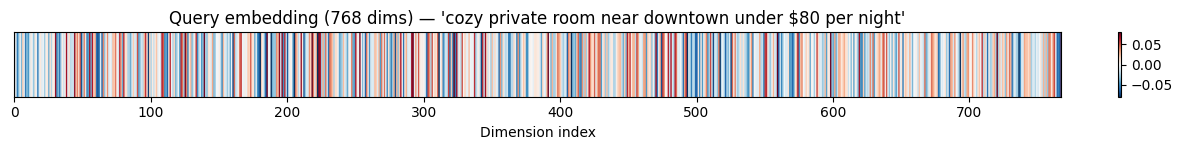

In [8]:
# ════════════════════════════════════════════════════════════════════════════
# RAG Step A1 — Embed the query                          [only runs on MISS]
# Source: app/rag.py  VS2Retriever.search()
#   query_vector = list(self._embedding_model.get_embeddings([query])[0].values)
# ════════════════════════════════════════════════════════════════════════════

if CACHE_HIT:
    print("⏭  Skipping A1 — cache HIT, no embedding needed.")
else:
    print("Step A1: Embedding query with text-embedding-005...")
    t0 = time.time()
    [emb_result] = embedding_model.get_embeddings([RAG_QUERY])
    elapsed_embed = time.time() - t0

    rag_query_vector = list(emb_result.values)   # 768 floats

    print(f"✓ Done in {elapsed_embed:.3f}s")
    print()
    print(f"  Input  : {RAG_QUERY!r}")
    print(f"  Output : list of {len(rag_query_vector)} floats")
    print(f"  Range  : [{min(rag_query_vector):.5f}, {max(rag_query_vector):.5f}]")
    print(f"  Norm   : {sum(v**2 for v in rag_query_vector)**0.5:.4f}  (unit vector after normalisation)")
    print(f"  First 6 values: {[round(v, 5) for v in rag_query_vector[:6]]}")
    print()
    print("  ► VS2.0 will find listing vectors closest to this 768-d point via ScaNN.")

    # Visualise the embedding
    vec = np.array(rag_query_vector)
    fig, ax = plt.subplots(figsize=(12, 1.6))
    ax.imshow(vec.reshape(1, -1), aspect="auto", cmap="RdBu_r", vmin=-0.08, vmax=0.08)
    ax.set_title(f"Query embedding (768 dims) — '{RAG_QUERY[:55]}'")
    ax.set_xlabel("Dimension index")
    ax.set_yticks([])
    plt.colorbar(ax.images[0], ax=ax, fraction=0.02)
    plt.tight_layout()
    plt.show()


In [9]:
# ════════════════════════════════════════════════════════════════════════════
# RAG Step A2 — VS2.0 SearchDataObjects (ANN / ScaNN)   [only runs on MISS]
# Source: app/rag.py  VS2Retriever.search()
#   request = vs.SearchDataObjectsRequest(
#       parent=self._collection,
#       vector_search=vs.VectorSearch(
#           vector=vs.DenseVector(values=query_vector),
#           search_field="embedding",
#           top_k=top_k,
#       ),
#   )
#   response = self._search_client.search_data_objects(request=request)
# ════════════════════════════════════════════════════════════════════════════

if CACHE_HIT:
    print("⏭  Skipping A2 — cache HIT, no Vector Search needed.")
else:
    print("Step A2: VS2.0 SearchDataObjects (ANN / ScaNN)...")
    print(f"  Collection  : {config.COLLECTION_RESOURCE}")
    print(f"  top_k       : {RAG_TOP_K}  (no over-fetch in /rag — exact top_k only)")
    print(f"  search_field: 'embedding'")
    print()

    search_request = vs.SearchDataObjectsRequest(
        parent=config.COLLECTION_RESOURCE,
        vector_search=vs.VectorSearch(
            vector=vs.DenseVector(values=rag_query_vector),
            search_field="embedding",
            top_k=RAG_TOP_K,        # /rag fetches EXACTLY top_k
        ),
    )

    t0 = time.time()
    search_response = search_client.search_data_objects(request=search_request)
    elapsed_search = time.time() - t0

    # ── Raw output: ONLY IDs + distances (no metadata!) ──────────────────────
    rag_hits = [
        (r.data_object.data_object_id, float(r.distance))
        for r in (search_response.results or [])
    ]

    print(f"✓ Search completed in {elapsed_search:.3f}s")
    print(f"  Results returned: {len(rag_hits)}")
    print()
    print("  ⚠  VS2.0 returns ONLY IDs and distances — metadata comes in Step A3.")
    print()
    print(f"  {'Rank':<6} {'DataObject ID (SHA-256 hash)':<46} {'Distance':<12}")
    print("  " + "─" * 66)
    for rank, (obj_id, dist) in enumerate(rag_hits, 1):
        print(f"  {rank:<6} {obj_id:<46} {dist:.6f}")


Step A2: VS2.0 SearchDataObjects (ANN / ScaNN)...
  Collection  : projects/deve-487713/locations/us-central1/collections/airbnb-listings-collection
  top_k       : 5  (no over-fetch in /rag — exact top_k only)
  search_field: 'embedding'

✓ Search completed in 0.623s
  Results returned: 5

  ⚠  VS2.0 returns ONLY IDs and distances — metadata comes in Step A3.

  Rank   DataObject ID (SHA-256 hash)                   Distance    
  ──────────────────────────────────────────────────────────────────
  1      fda1865e8d187462e08d20d97a7d2e3be335e2a8       0.740537
  2      997876f484f7e2fc64945eedf1d77e47f1be0c79       0.724335
  3      a55aac79db55076fc08da8a7b84bffbbda33fb6b       0.717427
  4      efdb77471d436de8ee983f78dd88ca086e7ed92f       0.715817
  5      f3ad9fe25071a1069461b08a9469589e83572ee5       0.713726


In [10]:
# ════════════════════════════════════════════════════════════════════════════
# RAG Step A3 — Parallel metadata fetch                  [only runs on MISS]
# Source: app/rag.py  VS2Retriever._fetch_data()  +  ThreadPoolExecutor block
#
#   with ThreadPoolExecutor(max_workers=min(len(hits), 10)) as pool:
#       futures = {pool.submit(self._fetch_data, obj_id): (obj_id, dist) ...}
#       for future in as_completed(futures):
#           obj_id, dist = futures[future]
#           data_map[obj_id] = (future.result(), dist)
# ════════════════════════════════════════════════════════════════════════════

if CACHE_HIT:
    print("⏭  Skipping A3 — cache HIT, no metadata fetch needed.")
else:
    print("Step A3: Fetching metadata for all results in parallel...")
    print(f"  Firing {len(rag_hits)} parallel get_data_object() calls (max 10 workers)")
    print()

    def _fetch_metadata(obj_id: str) -> dict:
        """Mirrors VS2Retriever._fetch_data() in app/rag.py"""
        name = f"{config.COLLECTION_RESOURCE}/dataObjects/{obj_id}"
        obj  = do_client.get_data_object(request=vs.GetDataObjectRequest(name=name))
        return dict(obj.data) if obj.data is not None else {}

    t0 = time.time()
    with ThreadPoolExecutor(max_workers=min(len(rag_hits), 10)) as pool:
        futures = {pool.submit(_fetch_metadata, oid): (oid, dist) for oid, dist in rag_hits}
        rag_data_map: dict[str, tuple[dict, float]] = {}
        for future in as_completed(futures):
            oid, dist = futures[future]
            rag_data_map[oid] = (future.result(), dist)
    elapsed_fetch = time.time() - t0

    print(f"✓ All metadata fetched in {elapsed_fetch:.3f}s  (parallel, {len(rag_data_map)} objects)")
    print()
    print(f"  Fields available per listing (_RETURN_FIELDS from app/rag.py):")
    print(f"  {_RETURN_FIELDS}")
    print()

    for rank, (oid, _dist) in enumerate(rag_hits, 1):
        data, score = rag_data_map[oid]
        name  = data.get("name", oid)
        price = data.get("price")
        rt    = data.get("room_type", "?")
        nb    = data.get("neighbourhood", "?")
        rating= data.get("rating")
        print(f"  [{rank}] {name}")
        print(f"       neighbourhood={nb!r}  room_type={rt!r}  "
              f"price=${price}/night  rating={rating}  score={score:.4f}")


Step A3: Fetching metadata for all results in parallel...
  Firing 5 parallel get_data_object() calls (max 10 workers)

✓ All metadata fetched in 0.449s  (parallel, 5 objects)

  Fields available per listing (_RETURN_FIELDS from app/rag.py):
  ['name', 'neighbourhood', 'property_type', 'room_type', 'accommodates', 'bedrooms', 'price', 'rating', 'instant_bookable', 'listing_url', 'host_name', 'text']

  [1] Private Room  in Walkable East Downtown House
       neighbourhood='78702'  room_type='Private room'  price=$250.0/night  rating=5.0  score=0.7405
  [2] Private Room, Convenient Location, Free Wifi
       neighbourhood='78758'  room_type='Private room'  price=$30.0/night  rating=4.83  score=0.7243
  [3] #Private Room - 10 minutes to Downtown Austin
       neighbourhood='78752'  room_type='Private room'  price=$46.0/night  rating=4.8  score=0.7174
  [4] Private room in central Austin
       neighbourhood='78723'  room_type='Private room'  price=$63.0/night  rating=5.0  score=0.7158
  

In [12]:
# ════════════════════════════════════════════════════════════════════════════
# RAG Step A4 — Build context string + sources list     [only runs on MISS]
# Source: app/rag.py  build_context(results: list[ListingResult])
#
# build_context() returns:  (context_string, sources_list)
#   context_string  → injected into the Gemini prompt
#   sources_list    → returned in RagResponse.sources (used by the UI)
#
# NOTE: sources includes the 'text' field (listing description snippet)
#       which was missing from the previous version of this notebook.
# ════════════════════════════════════════════════════════════════════════════

if CACHE_HIT:
    print("⏭  Skipping A4 — cache HIT.")
else:
    print("Step A4: Building context string + sources list (mirrors build_context())...")
    print()

    context_lines: list[str] = []
    rag_sources:   list[dict] = []

    for rank, (oid, _dist) in enumerate(rag_hits, 1):
        data, score = rag_data_map[oid]

        # ── Mirrors build_context() in app/rag.py EXACTLY ─────────────────────
        rag_sources.append({
            "rank":             rank,
            "id":               oid,
            "name":             data.get("name"),
            "neighbourhood":    data.get("neighbourhood"),
            "room_type":        data.get("room_type"),
            "price":            data.get("price"),
            "rating":           data.get("rating"),
            "accommodates":     data.get("accommodates"),
            "instant_bookable": data.get("instant_bookable"),
            "listing_url":      data.get("listing_url"),
            "host_name":        data.get("host_name"),
            "text":             data.get("text"),          # ← was missing before
            "score":            score,
        })

        # ── Context lines fed into the LLM prompt ─────────────────────────────
        context_lines.append(f"[{rank}] {data.get('name', oid)}")
        if data.get("neighbourhood"):   context_lines.append(f"Location: {data['neighbourhood']}")
        if data.get("room_type"):       context_lines.append(f"Type: {data['room_type']}")
        if data.get("price"):           context_lines.append(f"Price: ${data['price']:.0f}/night")
        if data.get("rating"):          context_lines.append(f"Rating: {data['rating']:.2f} \u2605")
        if data.get("accommodates"):    context_lines.append(f"Accommodates: {int(data['accommodates'])} guests")
        if data.get("bedrooms"):        context_lines.append(f"Bedrooms: {int(data['bedrooms'])}")
        if data.get("instant_bookable"):context_lines.append(f"Instant bookable: {data['instant_bookable']}")
        if data.get("listing_url"):     context_lines.append(f"URL: {data['listing_url']}")
        if data.get("text"):            context_lines.append(f"Description: {data['text'][:300]}")
        context_lines.append("")

    rag_context = "\n".join(context_lines).strip()

    print(f"  context_string length : {len(rag_context)} characters  (injected into Gemini prompt)")
    print(f"  sources list length   : {len(rag_sources)} items  (returned in RagResponse.sources)")
    print()
    print("  Context string (what Gemini will read):")
    print("  " + "─" * 58)
    print(rag_context)
    print("  " + "─" * 58)
    print()
    print("  Sources list field names (RagResponse.sources[i]):")
    print(f"  {list(rag_sources[0].keys()) if rag_sources else '[]'}")
    print("  ↑  Note: 'text' field included (listing description — was missing before)")


Step A4: Building context string + sources list (mirrors build_context())...

  context_string length : 2652 characters  (injected into Gemini prompt)
  sources list length   : 5 items  (returned in RagResponse.sources)

  Context string (what Gemini will read):
  ──────────────────────────────────────────────────────────
[1] Private Room  in Walkable East Downtown House
Location: 78702
Type: Private room
Price: $250/night
Rating: 5.00 ★
Accommodates: 1 guests
Bedrooms: 1
Instant bookable: false
URL: https://www.airbnb.com/rooms/16334187
Description: Private Room  in Walkable East Downtown House My guest room w/ private bathroom across the hall is located in a 3-bedroom house in east downtown Austin.  It is walkable to all of downtown, including the Austin Convention Center (10 min. walk), Cesar Chavez St, 6th St, and Rainey St.  Within a few bl

[2] Private Room, Convenient Location, Free Wifi
Location: 78758
Type: Private room
Price: $30/night
Rating: 4.83 ★
Accommodates: 2 guests
Be

In [13]:
# ════════════════════════════════════════════════════════════════════════════
# RAG Step A5 — Single LLM call (no tools)              [only runs on MISS]
# Source: app/main.py  rag() route — prompt construction + generate_content()
#
# The model is created WITHOUT tools=[...].
# Gemini can ONLY write text here — it cannot call find_rentals.
# ════════════════════════════════════════════════════════════════════════════

if CACHE_HIT:
    print("⏭  Skipping A5 — cache HIT, no LLM call needed.")
    elapsed_embed = elapsed_search = elapsed_fetch = elapsed_llm = 0.0
else:
    print("Step A5: Calling Gemini (one-shot, no tools)...")
    print()

    # ── Exact prompt from app/main.py rag() ──────────────────────────────────
    rag_prompt = f"""You are a helpful Airbnb rental assistant for Austin, Texas.
Answer the QUESTION using ONLY the listings in CONTEXT below.
If none of the listings match what the user is asking for, say so and suggest
what they could try instead.
Present matching listings clearly: name, location, price, size, rating, URL.

CONTEXT:
{rag_context}

QUESTION:
{RAG_QUERY}
"""

    print(f"  Prompt length : {len(rag_prompt)} chars")
    print(f"  Temperature   : {config.TEMPERATURE}  (low = deterministic)")
    print(f"  Max tokens    : {config.MAX_OUTPUT_TOKENS}")
    print()

    # ── Same as app/main.py get_model() — NO tools ───────────────────────────
    rag_model = GenerativeModel(
        model_name=config.GEMINI_MODEL,
        generation_config=GenerationConfig(
            temperature=config.TEMPERATURE,
            max_output_tokens=config.MAX_OUTPUT_TOKENS,
        ),
        # ← No system_instruction, no tools= — pure text generation
    )

    t0 = time.time()
    rag_resp   = rag_model.generate_content(rag_prompt)
    elapsed_llm = time.time() - t0

    rag_answer = (rag_resp.text or "").strip()

    print(f"✓ LLM responded in {elapsed_llm:.3f}s")
    print(f"  finish_reason  : {rag_resp.candidates[0].finish_reason}")
    try:
        usage = rag_resp.usage_metadata
        print(f"  prompt_tokens  : {usage.prompt_token_count}")
        print(f"  output_tokens  : {usage.candidates_token_count}")
    except Exception:
        pass
    print()
    print("  Generated answer:")
    print("  " + "─" * 58)
    print(rag_answer)


Step A5: Calling Gemini (one-shot, no tools)...

  Prompt length : 3033 chars
  Temperature   : 0.2  (low = deterministic)
  Max tokens    : 2048

✓ LLM responded in 4.990s
  finish_reason  : 1
  prompt_tokens  : 889
  output_tokens  : 195

  Generated answer:
  ──────────────────────────────────────────────────────────
Here are a couple of cozy private rooms near downtown under $80 per night:

*   **#Private Room - 10 minutes to Downtown Austin**
    *   Location: 78752 (10 minutes to Downtown Austin)
    *   Price: $46/night
    *   Accommodates: 1 guest
    *   Rating: 4.80 ★
    *   URL: https://www.airbnb.com/rooms/52899140

*   **Private room in central Austin**
    *   Location: 78723 (central Austin)
    *   Price: $63/night
    *   Accommodates: 2 guests
    *   Rating: 5.00 ★
    *   URL: https://www.airbnb.com/rooms/43675698


In [14]:
# ════════════════════════════════════════════════════════════════════════════
# RAG Step A6 — Cache WRITE + Final RagResponse         [only runs on MISS]
# Source: app/main.py  rag() route — set_cached() + return result
#
#   result = RagResponse(answer=answer, sources=sources,
#                        model=config.GEMINI_MODEL, collection=config.COLLECTION_RESOURCE)
#   set_cached(key, result.model_dump(), ttl=config.CACHE_RAG_TTL)
#   return result
# ════════════════════════════════════════════════════════════════════════════

if not CACHE_HIT:
    # ── Build RagResponse dict (mirrors RagResponse.model_dump()) ────────────
    rag_response = {
        "answer":     rag_answer,
        "sources":    rag_sources,
        "model":      config.GEMINI_MODEL,
        "collection": config.COLLECTION_RESOURCE,
    }

    # ── Write to cache so next identical query returns in <2ms ───────────────
    set_cached(_cache_key, rag_response, ttl=config.CACHE_RAG_TTL,
               endpoint="rag", query_preview=RAG_QUERY)

    print(f"✓ Cached under key : {_cache_key}")
    print(f"  TTL              : {config.CACHE_RAG_TTL}s  ({config.CACHE_RAG_TTL//3600}h)")
    print(f"  Stored           : RagResponse dict  (answer + {len(rag_sources)} sources)")
    print()
else:
    rag_response = _cached_result

print("═" * 60)
print("  FINAL  POST /rag  RESPONSE")
print("═" * 60)
print()
print("  answer (preview):")
print("  " + "─" * 58)
print((rag_response.get("answer") or "")[:500])
print()
print(f"  sources ({len(rag_response.get('sources', []))} listings):")
for s in rag_response.get("sources", []):
    p = s.get("price")
    sc = s.get("score")
    print(f"    [{s['rank']}] {s['name']}  |  ${p}/night  |  score={sc:.4f}")
print()
print(f"  model      : {rag_response['model']}")
print(f"  collection : {rag_response['collection']}")
print()
if not CACHE_HIT:
    total = elapsed_embed + elapsed_search + elapsed_fetch + elapsed_llm
    print("── Timing breakdown (MISS path) ────────────────────────────")
    print(f"  A0.5 cache check  : {elapsed_cache_check*1000:.1f} ms  (MISS)")
    print(f"  A1   embed query  : {elapsed_embed:.3f}s")
    print(f"  A2   ANN search   : {elapsed_search:.3f}s")
    print(f"  A3   metadata     : {elapsed_fetch:.3f}s  (parallel)")
    print(f"  A5   LLM call     : {elapsed_llm:.3f}s")
    print(f"  ──────────────────────────────────────────────────────────")
    print(f"  TOTAL /rag MISS   : {total:.3f}s  ({total*1000:.0f} ms)")
    print()
    print("── Re-run cell A0.5 now — it will show CACHE HIT at <2ms ──")
else:
    print(f"── Timing (HIT path) ───────────────────────────────────────")
    print(f"  Cache check + deserialise : {elapsed_cache_check*1000:.1f} ms")
    print(f"  Embed / Search / LLM      : 0 ms  (skipped entirely)")
    print(f"  TOTAL /rag HIT            : {elapsed_cache_check*1000:.1f} ms")


✓ Cached under key : rag:155fd8ac7a7d786d7e90ab27f9856298
  TTL              : 3600s  (1h)
  Stored           : RagResponse dict  (answer + 5 sources)

════════════════════════════════════════════════════════════
  FINAL  POST /rag  RESPONSE
════════════════════════════════════════════════════════════

  answer (preview):
  ──────────────────────────────────────────────────────────
Here are a couple of cozy private rooms near downtown under $80 per night:

*   **#Private Room - 10 minutes to Downtown Austin**
    *   Location: 78752 (10 minutes to Downtown Austin)
    *   Price: $46/night
    *   Accommodates: 1 guest
    *   Rating: 4.80 ★
    *   URL: https://www.airbnb.com/rooms/52899140

*   **Private room in central Austin**
    *   Location: 78723 (central Austin)
    *   Price: $63/night
    *   Accommodates: 2 guests
    *   Rating: 5.00 ★
    *   URL: https://www.

  sources (5 listings):
    [1] Private Room  in Walkable East Downtown House  |  $250.0/night  |  score=0.7405
 

---
# PART B — `POST /ask` (Agentic)

```
User query
    │
    ▼ Step B1 — Gemini + tools declared (FunctionDeclaration)
    │           model knows the find_rentals schema
    ▼ Step B2 — chat.send_message(query)  → Turn 1
    │           Gemini reasons about the query and issues a function_call
    ▼ Step B3 — Python reads the function_call from Gemini's response
    │           extracts: query, max_price, room_type, ... that Gemini chose
    ▼ Step B4 — find_rentals() executes (this is where search actually happens)
    │    ├── B4a  Embed query (semantic part only)
    │    ├── B4b  VS2.0 search — fetch_k = top_k × 4  (over-fetch!)
    │    ├── B4c  Parallel metadata fetch for ALL candidates
    │    ├── B4d  Python-side key-value filter pass
    │    └── B4e  Format results as string
    ▼ Step B5 — Tool result fed back to Gemini  → Turn 2
    │           Gemini reads listings and decides: answer OR retry
    ▼ Step B6 — If no results: Gemini relaxes filters, calls find_rentals again
    │           (loop up to max_turns=5)
    ▼ Final natural-language answer + full tool_calls audit log
```

> Gemini is the **brain** — it decides what to search for, what filters to apply, and whether to retry.

In [20]:
# ═══════════════════════════════════════════════════════════════════
# ASK Step B0 — The user's raw query (what POST /ask receives)
# ═══════════════════════════════════════════════════════════════════

ASK_QUERY = "cozy private room near downtown under $80 per night"
# Use the SAME query as /rag so we can compare behaviour directly

print("═" * 60)
print("  POST /ask")
print("═" * 60)
print(f"  query : {ASK_QUERY!r}")
print()
print("  What Gemini will need to figure out from this sentence:")
print("    • semantic search query  → 'cozy private room near downtown'")
print("    • room_type filter       → 'Private room'")
print("    • max_price filter       → 80.0")
print()
print("  Gemini extracts these at runtime — nothing is hardcoded.")

════════════════════════════════════════════════════════════
  POST /ask
════════════════════════════════════════════════════════════
  query : 'cozy private room near downtown under $80 per night'

  What Gemini will need to figure out from this sentence:
    • semantic search query  → 'cozy private room near downtown'
    • room_type filter       → 'Private room'
    • max_price filter       → 80.0

  Gemini extracts these at runtime — nothing is hardcoded.


In [21]:
# ═══════════════════════════════════════════════════════════════════
# ASK Step B1 — Declare the tool schema and boot the model
# Same as: agent.py lines 74-128 + 160-168
# ═══════════════════════════════════════════════════════════════════

print("Step B1: Declaring find_rentals tool schema for Gemini...")
print()

FIND_RENTALS_DECLARATION = FunctionDeclaration(
    name="find_rentals",
    description=(
        "Search for Airbnb rentals in Austin, TX using semantic vector search "
        "and optional metadata filters. Returns a list of matching listings."
    ),
    parameters={
        "type": "object",
        "properties": {
            "query":           {"type": "string",  "description": "Natural language description of the ideal rental"},
            "max_price":       {"type": "number",  "description": "Maximum price per night in USD"},
            "min_price":       {"type": "number",  "description": "Minimum price per night in USD"},
            "room_type":       {"type": "string",  "description": "Type of room",
                                "enum": ["Entire home/apt", "Private room", "Shared room", "Hotel room"]},
            "min_bedrooms":    {"type": "integer", "description": "Minimum number of bedrooms"},
            "neighbourhood":   {"type": "string",  "description": "Neighborhood name or zip code"},
            "instant_bookable":{"type": "boolean", "description": "True to only return instantly bookable listings"},
            "accommodates":    {"type": "integer", "description": "Minimum number of guests the listing must accommodate"},
            "top_k":           {"type": "integer", "description": "Number of results to return (default 8, max 20)"},
        },
        "required": ["query"],
    },
)

FIND_RENTALS_TOOL = Tool(function_declarations=[FIND_RENTALS_DECLARATION])

AGENT_SYSTEM_INSTRUCTION = """You are an expert Airbnb rental assistant for Austin, Texas.
You have access to a search tool called find_rentals that queries a database of
real Airbnb listings in Austin using semantic vector search.
Guidelines:
1. Extract constraints from the user's message and pass them as filters.
2. Always include a descriptive query so semantic search works well.
3. If the first search returns no results, retry with relaxed filters.
4. Present results clearly: name, location, price, size, rating, URL.
5. Be conversational and helpful — you're an expert local guide.
"""

# Model created WITH tools — this is the key difference from /rag
ask_model = GenerativeModel(
    model_name=config.GEMINI_MODEL,
    tools=[FIND_RENTALS_TOOL],                  # ← Gemini knows about find_rentals
    system_instruction=AGENT_SYSTEM_INSTRUCTION, # ← behaviour instructions
    generation_config=GenerationConfig(
        temperature=config.TEMPERATURE,
        max_output_tokens=config.MAX_OUTPUT_TOKENS,
    ),
)

print("  Tool schema (what Gemini knows about find_rentals):")
print(f"    name        : find_rentals")
print(f"    required    : query")
print(f"    optional    : max_price, min_price, room_type, min_bedrooms,")
print(f"                  neighbourhood, instant_bookable, accommodates, top_k")
print()
print(f"  ✓ GenerativeModel created with tools=[FIND_RENTALS_TOOL]")
print(f"  ✓ System instruction: {len(AGENT_SYSTEM_INSTRUCTION)} chars")

Step B1: Declaring find_rentals tool schema for Gemini...

  Tool schema (what Gemini knows about find_rentals):
    name        : find_rentals
    required    : query
    optional    : max_price, min_price, room_type, min_bedrooms,
                  neighbourhood, instant_bookable, accommodates, top_k

  ✓ GenerativeModel created with tools=[FIND_RENTALS_TOOL]
  ✓ System instruction: 562 chars


In [22]:
# ═══════════════════════════════════════════════════════════════════
# ASK Step B2 — Turn 1: send user query to Gemini
# Same as: agent.py lines 170-172
# ═══════════════════════════════════════════════════════════════════

print("Step B2: Sending user query to Gemini (Turn 1)...")
print(f"  → '{ASK_QUERY}'")
print()

chat     = ask_model.start_chat()
t0       = time.time()
response = chat.send_message(ASK_QUERY)
elapsed_turn1 = time.time() - t0

print(f"✓ Gemini responded in {elapsed_turn1:.3f}s")
print()
print(f"  finish_reason : {response.candidates[0].finish_reason}")
print(f"  num parts     : {len(response.candidates[0].content.parts)}")
print()
print("  ► Gemini did NOT return a text answer yet.")
print("    It returned a function_call instruction — it wants to search first.")

Step B2: Sending user query to Gemini (Turn 1)...
  → 'cozy private room near downtown under $80 per night'

✓ Gemini responded in 1.813s

  finish_reason : 1
  num parts     : 1

  ► Gemini did NOT return a text answer yet.
    It returned a function_call instruction — it wants to search first.


In [23]:
# ═══════════════════════════════════════════════════════════════════
# ASK Step B3 — Inspect Gemini's function_call (what it decided)
# Same as: agent.py lines 179-191
# ═══════════════════════════════════════════════════════════════════

print("Step B3: Reading Gemini's function_call from the response parts...")
print()

candidate = response.candidates[0]
fn_calls  = [
    part.function_call
    for part in candidate.content.parts
    if (
        hasattr(part, "function_call")
        and part.function_call is not None
        and getattr(part.function_call, "name", None)
    )
]

if fn_calls:
    fc   = fn_calls[0]
    args = dict(fc.args)

    print(f"  Gemini issued {len(fn_calls)} function_call(s):")
    print()
    print(f"  ┌─ function_call ─────────────────────────────────────")
    print(f"  │  name : {fc.name}")
    print(f"  │  args :")
    for k, v in args.items():
        print(f"  │    {k:<20} = {v!r}")
    print(f"  └──────────────────────────────────────────────────────")
    print()
    print("  ► This is Gemini's NLP parsing of the user query:")
    if "query" in args:
        print(f"    'query'     → semantic search string: {args['query']!r}")
    if "max_price" in args:
        print(f"    'max_price' → extracted from 'under $80': {args['max_price']}")
    if "room_type" in args:
        print(f"    'room_type' → extracted from 'private room': {args['room_type']!r}")
    if "neighbourhood" in args:
        print(f"    'neighbourhood' → extracted from 'near downtown': {args['neighbourhood']!r}")
else:
    print("  ⚠ No function_call found — Gemini answered directly (unusual for first turn)")
    print("  This can happen if the model is very confident, or the query is a greeting.")

Step B3: Reading Gemini's function_call from the response parts...

  Gemini issued 1 function_call(s):

  ┌─ function_call ─────────────────────────────────────
  │  name : find_rentals
  │  args :
  │    room_type            = 'Private room'
  │    query                = 'cozy private room'
  │    max_price            = 80
  │    neighbourhood        = 'Downtown'
  └──────────────────────────────────────────────────────

  ► This is Gemini's NLP parsing of the user query:
    'query'     → semantic search string: 'cozy private room'
    'max_price' → extracted from 'under $80': 80
    'room_type' → extracted from 'private room': 'Private room'
    'neighbourhood' → extracted from 'near downtown': 'Downtown'


In [24]:
# ═══════════════════════════════════════════════════════════════════
# ASK Step B4a — find_rentals: embed the SEMANTIC query
# Same as: tools.py find_rentals() lines 163-166
# ═══════════════════════════════════════════════════════════════════

if not fn_calls:
    print("Skipping B4a–B4e — Gemini answered directly without a tool call.")
else:
    fc   = fn_calls[0]
    args = dict(fc.args)

    # Parameters Gemini chose
    ask_query_text   = str(args.get("query", ASK_QUERY))
    ask_max_price    = float(args["max_price"]) if "max_price" in args else None
    ask_min_price    = float(args["min_price"]) if "min_price" in args else None
    ask_room_type    = str(args["room_type"]) if "room_type" in args else None
    ask_min_bedrooms = int(args["min_bedrooms"]) if "min_bedrooms" in args else None
    ask_neighbourhood= str(args["neighbourhood"]) if "neighbourhood" in args else None
    ask_inst_book    = bool(args["instant_bookable"]) if "instant_bookable" in args else None
    ask_accommodates = int(args["accommodates"]) if "accommodates" in args else None
    ask_top_k        = int(args.get("top_k", 8))
    ask_top_k        = min(max(ask_top_k, 1), 20)
    ask_fetch_k      = min(ask_top_k * 4, 80)   # over-fetch for filter room

    print("Step B4a: find_rentals() → Embedding the SEMANTIC part of the query...")
    print()
    print(f"  NOTE: Only 'query' goes to the embedding model.")
    print(f"  Filters (max_price={ask_max_price}, room_type={ask_room_type!r}) are")
    print(f"  used LATER in Python — they don't affect the embedding.")
    print()
    print(f"  Embedding: {ask_query_text!r}")

    t0 = time.time()
    [ask_emb_result] = embedding_model.get_embeddings([ask_query_text])
    elapsed_ask_embed = time.time() - t0
    ask_query_vector  = list(ask_emb_result.values)

    print(f"  ✓ Done in {elapsed_ask_embed:.3f}s — {len(ask_query_vector)}-dim vector")
    print()
    print(f"  top_k requested by Gemini : {ask_top_k}")
    print(f"  fetch_k (4× over-fetch)   : {ask_fetch_k}")
    print()
    print("  ► /ask over-fetches by 4× so the filter pass has enough candidates.")
    print("    /rag fetches exactly top_k — no room for post-search filters.")

Step B4a: find_rentals() → Embedding the SEMANTIC part of the query...

  NOTE: Only 'query' goes to the embedding model.
  Filters (max_price=80.0, room_type='Private room') are
  used LATER in Python — they don't affect the embedding.

  Embedding: 'cozy private room'
  ✓ Done in 0.264s — 768-dim vector

  top_k requested by Gemini : 8
  fetch_k (4× over-fetch)   : 32

  ► /ask over-fetches by 4× so the filter pass has enough candidates.
    /rag fetches exactly top_k — no room for post-search filters.


In [25]:
# ═══════════════════════════════════════════════════════════════════
# ASK Step B4b — find_rentals: VS2.0 semantic search (over-fetched)
# Same as: tools.py find_rentals() lines 169-181
# ═══════════════════════════════════════════════════════════════════

if not fn_calls:
    print("Skipping — no tool call made.")
else:
    print("Step B4b: find_rentals() → VS2.0 semantic search (over-fetched)...")
    print()
    print(f"  top_k in request = {ask_fetch_k}  (= {ask_top_k} × 4)")
    print()

    ask_search_req = vs.SearchDataObjectsRequest(
        parent=config.COLLECTION_RESOURCE,
        vector_search=vs.VectorSearch(
            vector=vs.DenseVector(values=ask_query_vector),
            search_field="embedding",
            top_k=ask_fetch_k,   # ← over-fetch!
        ),
    )

    t0 = time.time()
    ask_search_resp = search_client.search_data_objects(request=ask_search_req)
    elapsed_ask_search = time.time() - t0

    ask_hits = [
        (r.data_object.data_object_id, float(r.distance))
        for r in (ask_search_resp.results or [])
    ]

    print(f"  ✓ Search completed in {elapsed_ask_search:.3f}s")
    print(f"  Raw candidates returned: {len(ask_hits)}")
    print()
    print(f"  {'Rank':<6} {'ID (SHA1)':<44} {'Distance':<12}")
    print("  " + "─" * 64)
    for rank, (oid, dist) in enumerate(ask_hits[:12], 1):   # show first 12
        print(f"  {rank:<6} {oid:<44} {dist:.6f}")
    if len(ask_hits) > 12:
        print(f"  ... and {len(ask_hits)-12} more")
    print()
    print("  ⚠  Again — only IDs + distances returned. No metadata yet.")

Step B4b: find_rentals() → VS2.0 semantic search (over-fetched)...

  top_k in request = 32  (= 8 × 4)

  ✓ Search completed in 1.479s
  Raw candidates returned: 32

  Rank   ID (SHA1)                                    Distance    
  ────────────────────────────────────────────────────────────────
  1      50c08d278176312e2cd6139a3e7c9d43ee3b5eac     0.713514
  2      09596e93676706dd7a39372e4dcd196665f45bf5     0.712754
  3      be71a600d61bf8c8ee79ffd0eb8d0ec6cc4f382b     0.703248
  4      0d0e9f0ac84de3c969f23b31017a1ecd4902aa3f     0.694424
  5      c702f0983b94d13237c7a7a76ca7563983a29384     0.691738
  6      87938ce6588b1ca28c2177ae835748df89e61f35     0.690297
  7      3b5a7d8c0db497d3fa7a48f686e5d97bc8b6e99d     0.688986
  8      f43198055ad28b9dc9f3066ff040f722157ad461     0.688790
  9      b049cffb912b91b6c5792a700c10d6c2e5b45810     0.681602
  10     4168f6bb3ca1909c11912b0dbd9acfadf96ff9a6     0.677623
  11     f1eb58dc952ada8448811720298e0d93f8f30f7d     0.677396
  12   

In [26]:
# ═══════════════════════════════════════════════════════════════════
# ASK Step B4c — find_rentals: parallel metadata fetch for ALL candidates
# Same as: tools.py find_rentals() lines 183-196
# ═══════════════════════════════════════════════════════════════════

if not fn_calls:
    print("Skipping — no tool call made.")
else:
    print("Step B4c: find_rentals() → Fetching metadata for ALL candidates in parallel...")
    print(f"  Firing {len(ask_hits)} parallel get_data_object() calls")
    print()

    t0 = time.time()
    with ThreadPoolExecutor(max_workers=min(len(ask_hits), 10)) as pool:
        futures_ask    = {pool.submit(_fetch_metadata, oid): (oid, dist) for oid, dist in ask_hits}
        ask_data_map: dict[str, tuple[dict, float]] = {}
        for future in as_completed(futures_ask):
            oid, dist = futures_ask[future]
            ask_data_map[oid] = (future.result(), dist)
    elapsed_ask_fetch = time.time() - t0

    print(f"  ✓ All {len(ask_data_map)} metadata dicts fetched in {elapsed_ask_fetch:.3f}s")
    print()
    print("  Sample metadata for first 3 candidates (before filtering):")
    for rank, (oid, dist) in enumerate(ask_hits[:3], 1):
        data, score = ask_data_map[oid]
        print(f"    [{rank}] {data.get('name','?')[:45]:<45}  "
              f"${data.get('price',0):>6.0f}/night  "
              f"{data.get('room_type','?'):<20}  "
              f"score={score:.4f}")

Step B4c: find_rentals() → Fetching metadata for ALL candidates in parallel...
  Firing 32 parallel get_data_object() calls

  ✓ All 32 metadata dicts fetched in 0.502s

  Sample metadata for first 3 candidates (before filtering):
    [1] Plush & comforting                             $   855/night  Private room          score=0.7135
    [2] Convenient, private, plush, spacious master    $    49/night  Private room          score=0.7128
    [3] Cozy private room in S.Austin                  $    81/night  Private room          score=0.7032


In [27]:
ask_hits[0:3]

[('50c08d278176312e2cd6139a3e7c9d43ee3b5eac', 0.7135142087936401),
 ('09596e93676706dd7a39372e4dcd196665f45bf5', 0.7127538919448853),
 ('be71a600d61bf8c8ee79ffd0eb8d0ec6cc4f382b', 0.7032483816146851)]

In [28]:
ask_data_map

{'c702f0983b94d13237c7a7a76ca7563983a29384': ({'bathrooms_text': '1 shared bath',
   'beds': 1.0,
   'longitude': -97.58354,
   'price': 55.0,
   'rating': 4.96,
   'room_type': 'Private room',
   'instant_bookable': 'false',
   'host_name': 'Janice',
   'name': 'Cozy private bedroom in Southeast Austin.',
   'text': "Cozy private bedroom in Southeast Austin. Clean and cozy room with a full-size bed; best for 1 guest (can accommodate 2 for a fee). With a walk-in closet, and an office set-up. Room may be locked with a key. Bathroom is shared with the other room if it's booked (2 guests max). Otherwise, it's all yours. Basic bath necessities are provided. May use microwave, fridge, dining table, silverware, plates, mugs, and glasses in the kitchen. <br /><br />Airport transfers for a fee may be booked. Located in 78725. Private room. Accommodates 2 guests. We are in a new neighborhood in southeast Austin. The neighborhood is called Austin's Colony. 1 bedroom(s), 1 bed(s), 1 shared bath."

In [29]:
# ═══════════════════════════════════════════════════════════════════
# ASK Step B4d — find_rentals: Python-side key-value filter pass
# Same as: tools.py _passes_filters() + find_rentals() lines 198-214
#
# THIS IS THE KEY DIFFERENCE vs /rag:
#   Structured filters (price, room_type, etc.) are applied HERE in Python.
#   /rag has NO equivalent step — everything goes to the LLM unfiltered.
# ═══════════════════════════════════════════════════════════════════

if not fn_calls:
    print("Skipping — no tool call made.")
else:
    print("Step B4d: find_rentals() → Applying key-value filters in Python...")
    print()
    print("  Active filters (extracted by Gemini):")
    if ask_max_price    is not None: print(f"    max_price      = {ask_max_price}")
    if ask_min_price    is not None: print(f"    min_price      = {ask_min_price}")
    if ask_room_type    is not None: print(f"    room_type      = {ask_room_type!r}")
    if ask_min_bedrooms is not None: print(f"    min_bedrooms   = {ask_min_bedrooms}")
    if ask_neighbourhood is not None: print(f"    neighbourhood  = {ask_neighbourhood!r}")
    if ask_inst_book    is not None: print(f"    instant_bookable = {ask_inst_book}")
    if ask_accommodates is not None: print(f"    accommodates   = {ask_accommodates}")
    print()

    def _passes_filters(data, max_price, min_price, room_type,
                        min_bedrooms, neighbourhood, instant_bookable, accommodates):
        """Mirror of tools.py _passes_filters()"""
        price = data.get("price", 0.0)
        if max_price    is not None and price > max_price:                      return False
        if min_price    is not None and price < min_price:                      return False
        if room_type    is not None and data.get("room_type","").lower() != room_type.lower(): return False
        if min_bedrooms is not None and data.get("bedrooms", 0) < min_bedrooms: return False
        if neighbourhood is not None:
            if neighbourhood.lower() not in data.get("neighbourhood", "").lower(): return False
        if instant_bookable is not None:
            ib_val = data.get("instant_bookable", "false").lower() == "true"
            if ib_val != instant_bookable:                                      return False
        if accommodates is not None and data.get("accommodates", 0) < accommodates: return False
        return True

    print(f"  Evaluating all {len(ask_hits)} candidates:")
    print(f"  {'Rank':<5} {'Name':<40} {'Price':>8} {'RoomType':<22} {'PASS?':<6}")
    print("  " + "─" * 87)

    ask_filtered: list[tuple[dict, float]] = []
    for oid, dist in ask_hits:
        data, score = ask_data_map[oid]
        passed = _passes_filters(
            data,
            max_price=ask_max_price,
            min_price=ask_min_price,
            room_type=ask_room_type,
            min_bedrooms=ask_min_bedrooms,
            neighbourhood=ask_neighbourhood,
            instant_bookable=ask_inst_book,
            accommodates=ask_accommodates,
        )
        if passed:
            ask_filtered.append((data, score))

        rank_str = str(len(ask_filtered)) if passed else "-"
        pass_str = "✓ PASS" if passed else "✗ drop"
        name     = (data.get('name') or '?')[:38]
        price    = data.get('price', 0)
        rtype    = (data.get('room_type') or '')[:20]
        print(f"  {rank_str:<5} {name:<40} ${price:>6.0f}  {rtype:<22} {pass_str}")

    ask_filtered = ask_filtered[:ask_top_k]   # trim to final top_k

    print()
    print(f"  Candidates before filter : {len(ask_hits)}")
    print(f"  Candidates after filter  : {len(ask_filtered)}  (trimmed to top_k={ask_top_k})")
    print()
    print("  ► Only listings that pass ALL filters make it to the LLM.")
    print("    This is pure Python comparison — no database, no API call.")

Step B4d: find_rentals() → Applying key-value filters in Python...

  Active filters (extracted by Gemini):
    max_price      = 80.0
    room_type      = 'Private room'
    neighbourhood  = 'Downtown'

  Evaluating all 32 candidates:
  Rank  Name                                        Price RoomType               PASS? 
  ───────────────────────────────────────────────────────────────────────────────────────
  -     Plush & comforting                       $   855  Private room           ✗ drop
  -     Convenient, private, plush, spacious m   $    49  Private room           ✗ drop
  -     Cozy private room in S.Austin            $    81  Private room           ✗ drop
  -     Comfortable room with a living room ar   $    39  Private room           ✗ drop
  -     Cozy private bedroom in Southeast Aust   $    55  Private room           ✗ drop
  -     Adagio Room - B&BBQ / Cozy, Quiet & Co   $    40  Private room           ✗ drop
  -     Large Bedroom | Private Bath | Study N   $    35  P

In [31]:
# ═══════════════════════════════════════════════════════════════════
# ASK Step B4e — find_rentals: format results as a string
# Same as: tools.py _format_listing() + find_rentals() lines 216-248
# This string is what Python returns to Gemini as the tool result
# ═══════════════════════════════════════════════════════════════════

if not fn_calls:
    print("Skipping — no tool call made.")
else:
    def _format_listing(rank: int, data: dict, score: float) -> str:
        """Mirror of tools.py _format_listing()"""
        name   = data.get("name", "Unknown")
        nbhd   = data.get("neighbourhood", "")
        r_type = data.get("room_type", "")
        price  = data.get("price", 0.0)
        rating = data.get("rating", 0.0)
        beds   = int(data.get("bedrooms", 0))
        accom  = int(data.get("accommodates", 0))
        ib     = data.get("instant_bookable", "false")
        host   = data.get("host_name", "")
        url    = data.get("listing_url", "")
        text   = data.get("text", "")[:200]
        ib_str   = "✓ Instant Book" if ib == "true" else "Request required"
        beds_str = f"{beds} BR" if beds else "Studio"
        lines = [
            f"[{rank}] {name}",
            f"    📍 {nbhd}  |  🏠 {r_type}  |  {beds_str}  |  👥 {accom} guests",
            f"    💰 ${price:.0f}/night  |  ⭐ {rating:.2f}  |  {ib_str}",
            f"    Host: {host}",
            f"    {url}",
            f"    \"{text}\"",
        ]
        return "\n".join(lines)

    if ask_filtered:
        tool_result_lines = [
            f"Found {len(ask_filtered)} listing(s) in Austin, TX matching '{ask_query_text}':",
            "",
        ]
        for rank, (data, score) in enumerate(ask_filtered, 1):
            tool_result_lines.append(_format_listing(rank, data, score))
            tool_result_lines.append("")
    else:
        tool_result_lines = [
            f"No listings found matching your criteria. "
            f"Try broadening the search — e.g. increase max_price, relax room_type."
        ]

    ask_tool_result_str = "\n".join(tool_result_lines).strip()

    print("Step B4e: find_rentals() → Formatted result string (returned to Gemini):")
    print()
    print("  " + "─" * 58)
    print(ask_tool_result_str)
    print("  " + "─" * 58)
    print()
    print(f"  String length: {len(ask_tool_result_str)} chars")
    print()
    print("  ► This entire string is fed back to Gemini as the tool response.")
    print("    Gemini reads it and decides: answer now OR call find_rentals again.")

Step B4e: find_rentals() → Formatted result string (returned to Gemini):

  ──────────────────────────────────────────────────────────
No listings found matching your criteria. Try broadening the search — e.g. increase max_price, relax room_type.
  ──────────────────────────────────────────────────────────

  String length: 111 chars

  ► This entire string is fed back to Gemini as the tool response.
    Gemini reads it and decides: answer now OR call find_rentals again.


In [32]:
# ═══════════════════════════════════════════════════════════════════
# ASK Step B5 — Turn 2: feed tool result back to Gemini
# Same as: agent.py lines 205-213
# ═══════════════════════════════════════════════════════════════════

if not fn_calls:
    print("Skipping — no tool call made.")
else:
    print("Step B5: Sending tool result back to Gemini (Turn 2)...")
    print()

    tool_response_part = Part.from_function_response(
        name="find_rentals",
        response={"result": ask_tool_result_str},
    )

    t0 = time.time()
    response2 = chat.send_message([tool_response_part])
    elapsed_turn2 = time.time() - t0

    print(f"  ✓ Gemini responded in {elapsed_turn2:.3f}s")
    print(f"  finish_reason : {response2.candidates[0].finish_reason}")
    print(f"  num parts     : {len(response2.candidates[0].content.parts)}")
    print()

    # Check if Gemini wants to call the tool again
    fn_calls2 = [
        part.function_call
        for part in response2.candidates[0].content.parts
        if (
            hasattr(part, "function_call")
            and part.function_call is not None
            and getattr(part.function_call, "name", None)
        )
    ]

    if fn_calls2:
        print(f"  ► Gemini wants to call find_rentals AGAIN (refined search):")
        for fc2 in fn_calls2:
            print(f"    {fc2.name}({dict(fc2.args)})")
        print("    (in production agent.py, the loop continues up to max_turns=5)")
    else:
        print("  ► Gemini has enough information. No more tool calls. Producing final answer.")

Step B5: Sending tool result back to Gemini (Turn 2)...

  ✓ Gemini responded in 2.147s
  finish_reason : 1
  num parts     : 2

  ► Gemini wants to call find_rentals AGAIN (refined search):
    find_rentals({'room_type': 'Private room', 'query': 'cozy private room', 'max_price': 80})
    (in production agent.py, the loop continues up to max_turns=5)


In [34]:
# ═══════════════════════════════════════════════════════════════════
# ASK — Final Response (what POST /ask returns as JSON)
# Same as: agent.py lines 215-222 + main.py AgentResponse
# ═══════════════════════════════════════════════════════════════════

# Extract final text from whichever turn produced the answer
final_response = response2 if fn_calls else response
ask_final_text = ""
if final_response.candidates:
    for part in (final_response.candidates[0].content.parts or []):
        if hasattr(part, "text") and part.text:
            ask_final_text += part.text

ask_tool_calls_log = [
    {
        "tool":   fc.name,
        "args":   dict(fc.args),
        "result": ask_tool_result_str[:300] + "…" if len(ask_tool_result_str) > 300 else ask_tool_result_str,
    }
] if fn_calls else []

print("═" * 60)
print("  FINAL /ask RESPONSE")
print("═" * 60)
print()
print("  answer:")
print("  " + "─" * 58)
print(ask_final_text.strip())
print()
print("  tool_calls (full audit trail):")
for i, tc in enumerate(ask_tool_calls_log, 1):
    print(f"    [{i}] {tc['tool']}(")
    for k, v in tc['args'].items():
        print(f"           {k}={v!r}")
    print(f"         )")
print()
print("  model      :", config.GEMINI_MODEL)
print("  collection :", config.COLLECTION_RESOURCE)
print()
total_ask = elapsed_turn1 + elapsed_ask_embed + elapsed_ask_search + elapsed_ask_fetch + elapsed_turn2
print("── Timing Summary ──────────────────────────────────────")
print(f"  B2 Gemini turn 1 (reasoning) : {elapsed_turn1:.3f}s")
print(f"  B4a embed query              : {elapsed_ask_embed:.3f}s")
print(f"  B4b VS2.0 search (over-fetch): {elapsed_ask_search:.3f}s")
print(f"  B4c metadata fetch (parallel): {elapsed_ask_fetch:.3f}s")
print(f"  B5 Gemini turn 2 (answer)    : {elapsed_turn2:.3f}s")
print(f"  ─────────────────────────────────────────────────────")
print(f"  TOTAL /ask                   : {total_ask:.3f}s")

════════════════════════════════════════════════════════════
  FINAL /ask RESPONSE
════════════════════════════════════════════════════════════

  answer:
  ──────────────────────────────────────────────────────────
It looks like there are no private rooms available in Downtown Austin for under $80. Let's try searching for cozy private rooms under $80 in other neighborhoods in Austin.

  tool_calls (full audit trail):
    [1] find_rentals(
           room_type='Private room'
           query='cozy private room'
           max_price=80
           neighbourhood='Downtown'
         )

  model      : gemini-2.5-flash
  collection : projects/deve-487713/locations/us-central1/collections/airbnb-listings-collection

── Timing Summary ──────────────────────────────────────
  B2 Gemini turn 1 (reasoning) : 1.813s
  B4a embed query              : 0.264s
  B4b VS2.0 search (over-fetch): 1.479s
  B4c metadata fetch (parallel): 0.502s
  B5 Gemini turn 2 (answer)    : 2.147s
  ──────────────────────

---
# PART C — Side-by-Side Comparison
Visual summary of how the two pipelines differ step by step.

In [35]:
# ═══════════════════════════════════════════════════════════════════
# Comparison: Structured summary of what happened in both pipelines
# ═══════════════════════════════════════════════════════════════════

print("═" * 80)
print(f"  QUERY: {RAG_QUERY!r}")
print("═" * 80)
print()
print(f"  {'Dimension':<32} {'POST /rag':<22} {'POST /ask':<22}")
print("  " + "─" * 78)
rows = [
    ("Who decides what to search?",    "Hardcoded Python",        "Gemini (LLM)"),
    ("Semantic search?",               "✓ Yes",                   "✓ Yes"),
    ("Price filter ($80)?",            "✗ No",                    "✓ Yes (Gemini extracted)"),
    ("Room type filter?",              "✗ No",                    "✓ Yes (Gemini extracted)"),
    ("Fetch count",                    f"Exactly {RAG_TOP_K}",    f"{ask_top_k}×4={ask_fetch_k} (over-fetch)"),
    ("Python-side filter pass?",       "✗ No",                    "✓ Yes (_passes_filters)"),
    ("LLM calls",                      "1  (format only)",        "2  (reason + format)"),
    ("Tool calls",                     "0",                        f"{len(ask_tool_calls_log)}"),
    ("Retry on no results?",           "✗ No",                    "✓ Yes (up to 5 turns)"),
    ("Embed step timing",              f"{elapsed_embed:.3f}s",    f"{elapsed_ask_embed:.3f}s"),
    ("VS2.0 search timing",            f"{elapsed_search:.3f}s",  f"{elapsed_ask_search:.3f}s"),
    ("Metadata fetch timing",          f"{elapsed_fetch:.3f}s",   f"{elapsed_ask_fetch:.3f}s"),
    ("Total timing",
     f"{elapsed_embed+elapsed_search+elapsed_fetch+elapsed_llm:.3f}s",
     f"{total_ask:.3f}s"),
]
for label, rag_val, ask_val in rows:
    print(f"  {label:<32} {rag_val:<22} {ask_val:<22}")

print()
print("  KEY INSIGHT:")
print("    /rag  — semantic search + LLM formatting. Simple, fast.")
print("            Filters in the query ('$80') are IGNORED by the retrieval.")
print("    /ask  — Gemini reads the query, extracts filters, calls find_rentals,")
print("            which runs semantic search + Python key-value filter.")
print("            Slower but respects ALL constraints from the user.")

════════════════════════════════════════════════════════════════════════════════
  QUERY: 'cozy private room near downtown under $80 per night'
════════════════════════════════════════════════════════════════════════════════

  Dimension                        POST /rag              POST /ask             
  ──────────────────────────────────────────────────────────────────────────────
  Who decides what to search?      Hardcoded Python       Gemini (LLM)          
  Semantic search?                 ✓ Yes                  ✓ Yes                 
  Price filter ($80)?              ✗ No                   ✓ Yes (Gemini extracted)
  Room type filter?                ✗ No                   ✓ Yes (Gemini extracted)
  Fetch count                      Exactly 5              8×4=32 (over-fetch)   
  Python-side filter pass?         ✗ No                   ✓ Yes (_passes_filters)
  LLM calls                        1  (format only)       2  (reason + format)  
  Tool calls                       0    

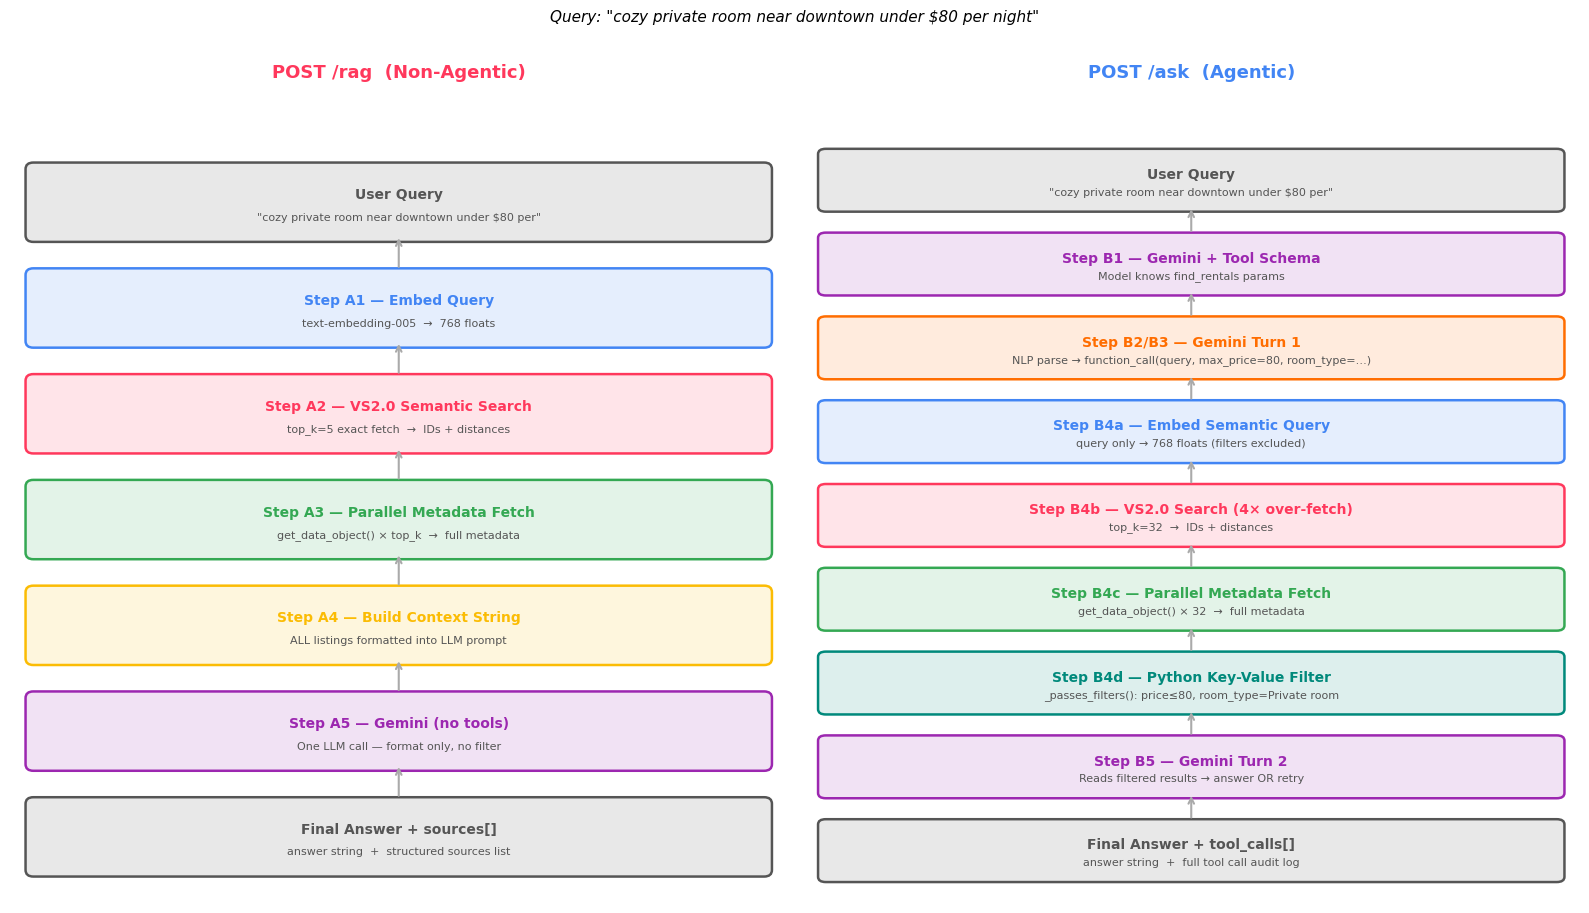

In [36]:
# ═══════════════════════════════════════════════════════════════════
# Visual pipeline diagram for both endpoints
# ═══════════════════════════════════════════════════════════════════

fig, axes = plt.subplots(1, 2, figsize=(16, 9))

def draw_pipeline(ax, title, steps, color):
    ax.axis("off")
    ax.set_xlim(0, 10)
    ax.set_ylim(0, len(steps) * 1.6 + 1)
    ax.set_title(title, fontsize=13, fontweight="bold", color=color, pad=14)

    for i, (label, sublabel, box_color) in enumerate(steps):
        y = (len(steps) - 1 - i) * 1.6 + 0.5

        # Box
        box = mpatches.FancyBboxPatch(
            (0.3, y), 9.4, 1.0,
            boxstyle="round,pad=0.1",
            linewidth=1.8, edgecolor=box_color, facecolor=box_color + "22"
        )
        ax.add_patch(box)
        ax.text(5, y + 0.62, label,   ha="center", va="center",
                fontsize=10, fontweight="bold", color=box_color)
        ax.text(5, y + 0.28, sublabel, ha="center", va="center",
                fontsize=8,  color="#555")

        # Arrow (skip for last)
        if i < len(steps) - 1:
            ax.annotate("", xy=(5, y), xytext=(5, y - 0.52),
                        arrowprops=dict(arrowstyle="->", color="#aaa", lw=1.5))

# ── /rag pipeline ────────────────────────────────────────────────────────────
rag_steps = [
    ("User Query",                     f'"{RAG_QUERY[:45]}"',             "#555555"),
    ("Step A1 — Embed Query",          "text-embedding-005  →  768 floats",  "#4285F4"),
    ("Step A2 — VS2.0 Semantic Search",f"top_k={RAG_TOP_K} exact fetch  →  IDs + distances", "#FF385C"),
    ("Step A3 — Parallel Metadata Fetch","get_data_object() × top_k  →  full metadata", "#34A853"),
    ("Step A4 — Build Context String", "ALL listings formatted into LLM prompt",   "#FBBC04"),
    ("Step A5 — Gemini (no tools)",    "One LLM call — format only, no filter",     "#9C27B0"),
    ("Final Answer + sources[]",       "answer string  +  structured sources list", "#555555"),
]
draw_pipeline(axes[0], "POST /rag  (Non-Agentic)", rag_steps, "#FF385C")

# ── /ask pipeline ────────────────────────────────────────────────────────────
ask_steps = [
    ("User Query",                     f'"{ASK_QUERY[:45]}"',              "#555555"),
    ("Step B1 — Gemini + Tool Schema", "Model knows find_rentals params",   "#9C27B0"),
    ("Step B2/B3 — Gemini Turn 1",     "NLP parse → function_call(query, max_price=80, room_type=…)", "#FF6D00"),
    ("Step B4a — Embed Semantic Query","query only → 768 floats (filters excluded)","#4285F4"),
    ("Step B4b — VS2.0 Search (4× over-fetch)",f"top_k={ask_fetch_k}  →  IDs + distances","#FF385C"),
    ("Step B4c — Parallel Metadata Fetch",f"get_data_object() × {len(ask_hits)}  →  full metadata", "#34A853"),
    ("Step B4d — Python Key-Value Filter","_passes_filters(): price≤80, room_type=Private room","#00897B"),
    ("Step B5 — Gemini Turn 2",        "Reads filtered results → answer OR retry",  "#9C27B0"),
    ("Final Answer + tool_calls[]",    "answer string  +  full tool call audit log", "#555555"),
]
draw_pipeline(axes[1], "POST /ask  (Agentic)", ask_steps, "#4285F4")

plt.suptitle(
    f'Query: "{RAG_QUERY}"',
    fontsize=11, y=1.01, style="italic"
)
plt.tight_layout()
plt.show()

Semantic similarity between the two query vectors:

  /rag embeds : 'cozy private room near downtown under $80 per night'
  /ask embeds : 'cozy private room'  (Gemini extracted this semantic part)

  Dot product similarity  : 0.7946
  Cosine similarity       : 0.7946  (1.0 = identical)



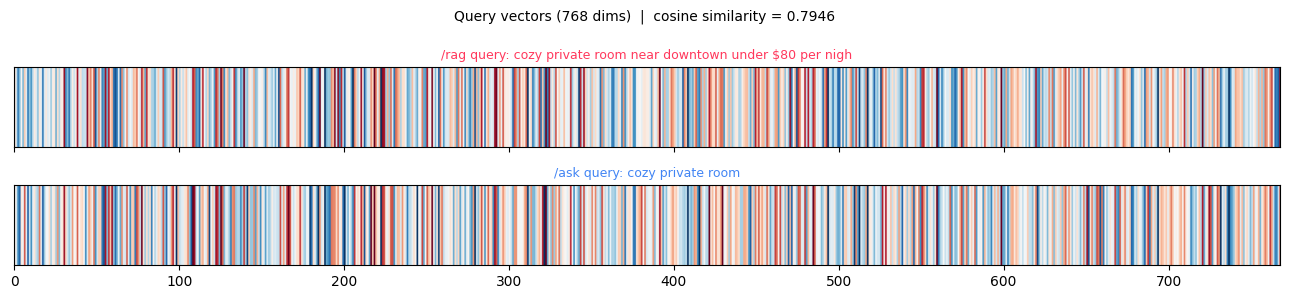

  ► Even though /ask uses a shorter, cleaner query string (Gemini strips
    the '$80' price constraint out of it), the vector spaces are very similar.
    The price is handled by the filter — not the embedding.


In [27]:
# ═══════════════════════════════════════════════════════════════════
# Semantic search comparison: /rag vs /ask used slightly different
# query strings — visualise the cosine similarity between the two vectors
# ═══════════════════════════════════════════════════════════════════

v_rag = np.array(rag_query_vector)
v_ask = np.array(ask_query_vector)

dot      = float(np.dot(v_rag, v_ask))
norm_rag = float(np.linalg.norm(v_rag))
norm_ask = float(np.linalg.norm(v_ask))
cosine   = dot / (norm_rag * norm_ask)

print("Semantic similarity between the two query vectors:")
print()
print(f"  /rag embeds : {RAG_QUERY!r}")
print(f"  /ask embeds : {ask_query_text!r}  (Gemini extracted this semantic part)")
print()
print(f"  Dot product similarity  : {dot:.4f}")
print(f"  Cosine similarity       : {cosine:.4f}  (1.0 = identical)")
print()

fig, axes = plt.subplots(2, 1, figsize=(13, 3), sharex=True)
for ax, vec, label, color in zip(
    axes,
    [v_rag, v_ask],
    [f"/rag query: {RAG_QUERY[:50]}", f"/ask query: {ask_query_text[:50]}"],
    ["#FF385C", "#4285F4"]
):
    ax.imshow(vec.reshape(1, -1), aspect="auto", cmap="RdBu_r", vmin=-0.08, vmax=0.08)
    ax.set_title(label, fontsize=9, color=color)
    ax.set_yticks([])
plt.suptitle(f"Query vectors (768 dims)  |  cosine similarity = {cosine:.4f}", fontsize=10)
plt.tight_layout()
plt.show()

print("  ► Even though /ask uses a shorter, cleaner query string (Gemini strips")
print("    the '$80' price constraint out of it), the vector spaces are very similar.")
print("    The price is handled by the filter — not the embedding.")

In [28]:
# ═══════════════════════════════════════════════════════════════════
# Final: compare raw results returned by each endpoint for the same query
# ═══════════════════════════════════════════════════════════════════

print(f"{'═'*80}")
print(f"  RESULTS COMPARISON for: {RAG_QUERY!r}")
print(f"{'═'*80}")
print()

print("  /rag results (all retrieved, no price/room filter):")
print(f"  {'Rank':<5} {'Name':<40} {'Price':>8} {'Room Type':<22} {'Score'}")
print("  " + "─" * 84)
for rank, (oid, dist) in enumerate(rag_hits, 1):
    data, score = rag_data_map[oid]
    name  = (data.get('name') or '?')[:38]
    price = data.get('price', 0)
    rtype = (data.get('room_type') or '')[:20]
    over  = "  ⚠ over $80" if price > 80 else ""
    wrong = "  ⚠ not Private room" if rtype != "Private room" else ""
    print(f"  {rank:<5} {name:<40} ${price:>6.0f}  {rtype:<22} {score:.4f}{over}{wrong}")

print()
print("  /ask results (price≤$80 + Private room enforced):")
print(f"  {'Rank':<5} {'Name':<40} {'Price':>8} {'Room Type':<22} {'Score'}")
print("  " + "─" * 84)
for rank, (data, score) in enumerate(ask_filtered, 1):
    name  = (data.get('name') or '?')[:38]
    price = data.get('price', 0)
    rtype = (data.get('room_type') or '')[:20]
    print(f"  {rank:<5} {name:<40} ${price:>6.0f}  {rtype:<22} {score:.4f}")

print()
print("  ► /rag may include listings above $80 or with wrong room type.")
print("    /ask guarantees every result satisfies the user's constraints.")

════════════════════════════════════════════════════════════════════════════════
  RESULTS COMPARISON for: 'cozy private room near downtown under $80 per night'
════════════════════════════════════════════════════════════════════════════════

  /rag results (all retrieved, no price/room filter):
  Rank  Name                                        Price Room Type              Score
  ────────────────────────────────────────────────────────────────────────────────────
  1     Private Room  in Walkable East Downtow   $   250  Private room           0.7405  ⚠ over $80
  2     Private Room, Convenient Location, Fre   $    30  Private room           0.7243
  3     #Private Room - 10 minutes to Downtown   $    46  Private room           0.7174
  4     Private room in central Austin           $    63  Private room           0.7158
  5     Curtained, Private Room, Convenient Lo   $    27  Private room           0.7137

  /ask results (price≤$80 + Private room enforced):
  Rank  Name            